# 12. Multitemporal DoD pipeline

Construye diferencias de elevación (`dH = DEM_epoch - DEM_base`) usando únicamente la capa final seleccionada, y exporta productos listos para análisis glaciar posterior.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import sys
import os

REPO_PATH = Path('/content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo')
SRC_PATH = REPO_PATH / 'src'

assert REPO_PATH.exists(), f'No existe: {REPO_PATH}'
assert SRC_PATH.exists(), f'No existe: {SRC_PATH}'

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

os.chdir(REPO_PATH)
print('REPO_PATH:', REPO_PATH)
print('SRC_PATH :', SRC_PATH)

REPO_PATH: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo
SRC_PATH : /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/src


In [3]:
!pip install xdem geoutils rasterio scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.0/208.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.3/177.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.1 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [4]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

import xdem
import geoutils as gu

from projectio.paths import Paths

## Configuración

In [5]:
cfg = Paths(REPO_PATH)

BASE_EPOCH = '2025_B'

FINAL_DIR = REPO_PATH / 'outputs' / 'coregistration_final'
SELECTED_DIR = REPO_PATH / 'outputs' / 'coregistration_selected'
DOD_DIR = REPO_PATH / 'outputs' / 'dod'
DOD_FIG_DIR = DOD_DIR / 'figures'
DOD_MAP_DIR = DOD_DIR / 'maps'
DOD_TABLE_DIR = DOD_DIR / 'tables'

for p in [DOD_DIR, DOD_FIG_DIR, DOD_MAP_DIR, DOD_TABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

selection_csv = FINAL_DIR / 'selection_manifest.csv'
dod_ready_csv = FINAL_DIR / 'dod_ready_epochs.csv'
mask_path = Path('/content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/Datos_Originales/mascaras/poligono_roca_estable/poligono_roca_estable.shp')

assert selection_csv.exists(), f'No existe: {selection_csv}'
assert dod_ready_csv.exists(), f'No existe: {dod_ready_csv}'
assert mask_path.exists(), f'No existe: {mask_path}'

print('selection_csv:', selection_csv)
print('dod_ready_csv:', dod_ready_csv)
print('mask_path    :', mask_path)
print('DOD_DIR      :', DOD_DIR)

selection_csv: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_final/selection_manifest.csv
dod_ready_csv: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_final/dod_ready_epochs.csv
mask_path    : /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/Datos_Originales/mascaras/poligono_roca_estable/poligono_roca_estable.shp
DOD_DIR      : /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/dod


## Carga de manifiestos

In [6]:
selection_df = pd.read_csv(selection_csv)
dod_ready_df = pd.read_csv(dod_ready_csv)

print('selection_df:', len(selection_df))
print('dod_ready_df:', len(dod_ready_df))

display(selection_df)
display(dod_ready_df)

selection_df: 6
dod_ready_df: 5


,epoch,base_epoch,best_raw_scenario,mean_after,median_after,std_after,nmad_after,mean_improved,median_improved,std_improved,nmad_improved,decision,selected_product,decision_rationale,original_path,corrected_path,selected_path,ready_for_dod
0,2017,2025_B,stable_raw_raw,3.371101,1.130371,5.271004,3.681163,True,True,True,True,use_corrected,corrected,La corrección mejora ajuste central y robusto.,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,True
1,2018,2025_B,stable_raw_raw,-2.107840,-2.006836,5.271650,5.250634,True,True,False,False,review,review,El resultado es mixto y debe revisarse antes d...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,NaN,False
2,2020,2025_B,stable_no_border_raw,-0.908376,-0.716797,5.858963,6.162418,True,True,True,True,use_corrected,corrected,La corrección mejora ajuste central y robusto.,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,True
3,2023,2025_B,stable_no_border_raw,1.288092,0.092285,2.310035,0.323595,True,True,True,False,use_corrected_nearly_neutral,corrected,La corrección tiene efecto pequeño y no perjud...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,True
4,2025_A,2025_B,stable_no_border_raw,0.115684,0.036621,0.443959,0.097006,False,False,True,False,use_original,original,La corrección empeora el ajuste central; se co...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,True
5,2025_B,2025_B,base_reference,0.000000,0.000000,0.000000,0.000000,True,True,True,True,base_reference,original,DEM base de referencia para todo el proyecto.,/content/drive/MyDrive/geo_projects/llojeta-gl...,NaN,/content/drive/MyDrive/geo_projects/llojeta-gl...,True


,epoch,base_epoch,best_raw_scenario,mean_after,median_after,std_after,nmad_after,mean_improved,median_improved,std_improved,nmad_improved,decision,selected_product,decision_rationale,original_path,corrected_path,selected_path,ready_for_dod
0,2017,2025_B,stable_raw_raw,3.371101,1.130371,5.271004,3.681163,True,True,True,True,use_corrected,corrected,La corrección mejora ajuste central y robusto.,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,True
1,2020,2025_B,stable_no_border_raw,-0.908376,-0.716797,5.858963,6.162418,True,True,True,True,use_corrected,corrected,La corrección mejora ajuste central y robusto.,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,True
2,2023,2025_B,stable_no_border_raw,1.288092,0.092285,2.310035,0.323595,True,True,True,False,use_corrected_nearly_neutral,corrected,La corrección tiene efecto pequeño y no perjud...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,True
3,2025_A,2025_B,stable_no_border_raw,0.115684,0.036621,0.443959,0.097006,False,False,True,False,use_original,original,La corrección empeora el ajuste central; se co...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,True
4,2025_B,2025_B,base_reference,0.000000,0.000000,0.000000,0.000000,True,True,True,True,base_reference,original,DEM base de referencia para todo el proyecto.,/content/drive/MyDrive/geo_projects/llojeta-gl...,NaN,/content/drive/MyDrive/geo_projects/llojeta-gl...,True


## Helpers

In [7]:
def bool_data_from_dem(dem):
    arr = np.asarray(dem.data)
    if arr.ndim == 3:
        arr = arr[0]
    return np.asarray(arr)

def clean_values(arr):
    arr = np.asarray(arr, dtype='float64')
    arr = arr[np.isfinite(arr)]
    arr = arr[arr != -9999]
    return arr

def nmad(arr):
    arr = np.asarray(arr, dtype='float64')
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan
    med = np.nanmedian(arr)
    return 1.4826 * np.nanmedian(np.abs(arr - med))

def summarize_dh(arr, label):
    arr = clean_values(arr)
    if arr.size == 0:
        return {
            'label': label, 'n': 0,
            'mean': np.nan, 'median': np.nan, 'std': np.nan, 'nmad': np.nan,
            'min': np.nan, 'max': np.nan,
            'p01': np.nan, 'p05': np.nan, 'p25': np.nan,
            'p75': np.nan, 'p95': np.nan, 'p99': np.nan,
            'mean_abs': np.nan, 'median_abs': np.nan
        }
    return {
        'label': label,
        'n': int(arr.size),
        'mean': float(np.nanmean(arr)),
        'median': float(np.nanmedian(arr)),
        'std': float(np.nanstd(arr)),
        'nmad': float(nmad(arr)),
        'min': float(np.nanmin(arr)),
        'max': float(np.nanmax(arr)),
        'p01': float(np.nanpercentile(arr, 1)),
        'p05': float(np.nanpercentile(arr, 5)),
        'p25': float(np.nanpercentile(arr, 25)),
        'p75': float(np.nanpercentile(arr, 75)),
        'p95': float(np.nanpercentile(arr, 95)),
        'p99': float(np.nanpercentile(arr, 99)),
        'mean_abs': float(np.nanmean(np.abs(arr))),
        'median_abs': float(np.nanmedian(np.abs(arr))),
    }

def save_geotiff(arr2d, ref_dem, out_path):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    arr2d = np.asarray(arr2d)
    if arr2d.ndim == 3:
        arr2d = arr2d[0]
    arr2d = arr2d.astype('float32')

    transform = getattr(ref_dem, 'transform', None)
    crs = getattr(ref_dem, 'crs', None)

    if transform is None:
        raise AttributeError("ref_dem no expone atributo 'transform'")
    if crs is None:
        raise AttributeError("ref_dem no expone atributo 'crs'")

    height, width = arr2d.shape

    with rasterio.open(
        out_path,
        'w',
        driver='GTiff',
        height=height,
        width=width,
        count=1,
        dtype='float32',
        crs=crs,
        transform=transform,
        nodata=np.nan,
        compress='deflate',
    ) as dst:
        dst.write(arr2d, 1)

def plot_dh_map(arr2d, epoch, out_png):
    valid = arr2d[np.isfinite(arr2d)]
    if valid.size == 0:
        print(f'[{epoch}] Sin valores válidos para figura.')
        return
    lim = np.nanpercentile(np.abs(valid), 98)
    if not np.isfinite(lim) or lim == 0:
        lim = 1.0

    fig = plt.figure(figsize=(8, 6))
    plt.imshow(arr2d, vmin=-lim, vmax=lim)
    plt.title(f'dH = {epoch} - {BASE_EPOCH}')
    plt.colorbar(shrink=0.8)
    plt.tight_layout()
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

## Resolver capa seleccionada

In [8]:
dod_ready_df['epoch'] = dod_ready_df['epoch'].astype(str).str.strip()
dod_ready_df = dod_ready_df[dod_ready_df['ready_for_dod'] == True].copy()

base_row = dod_ready_df[dod_ready_df['epoch'] == BASE_EPOCH].copy()
assert len(base_row) == 1, f'Debe existir exactamente una fila base para {BASE_EPOCH}'

base_selected_path = Path(base_row.iloc[0]['selected_path'])
assert base_selected_path.exists(), f'No existe base seleccionada: {base_selected_path}'

target_rows = dod_ready_df[dod_ready_df['epoch'] != BASE_EPOCH].copy()
target_rows = target_rows.sort_values('epoch').reset_index(drop=True)

print('Base selected path:', base_selected_path)
display(target_rows[['epoch', 'selected_product', 'selected_path', 'decision', 'ready_for_dod']])

Base selected path: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_selected/2025_B_DSM_selected.tif


,epoch,selected_product,selected_path,decision,ready_for_dod
0,2017,corrected,/content/drive/MyDrive/geo_projects/llojeta-gl...,use_corrected,True
1,2020,corrected,/content/drive/MyDrive/geo_projects/llojeta-gl...,use_corrected,True
2,2023,corrected,/content/drive/MyDrive/geo_projects/llojeta-gl...,use_corrected_nearly_neutral,True
3,2025_A,original,/content/drive/MyDrive/geo_projects/llojeta-gl...,use_original,True


## Cargar DEM base y máscara de roca estable

In [9]:
base_dem = xdem.DEM(base_selected_path)
mask_vector = gu.Vector(mask_path)
stable_mask = mask_vector.create_mask(base_dem)
stable_mask = np.asarray(stable_mask)
if stable_mask.ndim == 3:
    stable_mask = stable_mask[0]
stable_mask = stable_mask.astype(bool)

base_arr = bool_data_from_dem(base_dem)
base_valid = np.isfinite(base_arr) & (base_arr != -9999)

print('Base shape   :', base_dem.shape)
print('Base res     :', base_dem.res)
print('Base crs     :', base_dem.crs)
print('Stable pixels:', int(stable_mask.sum()))
print('Base valid   :', int(base_valid.sum()))

Base shape   : (2172, 2588)
Base res     : (0.5, 0.5)
Base crs     : EPSG:32719
Stable pixels: 1
Base valid   : 3391183


## Construcción batch de DoD


[2017] ==============================================
selected_path   : /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_selected/2017_DSM_selected.tif
selected_product: corrected
decision        : use_corrected


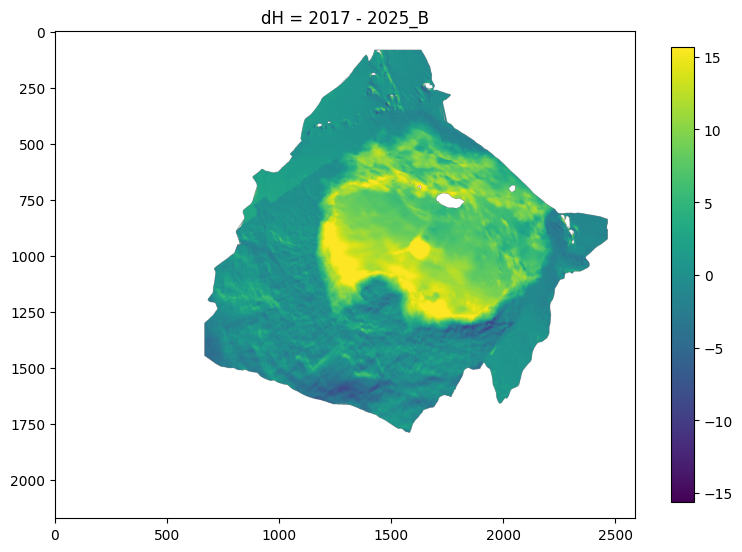

stable mean/median/std/nmad: 3.3625231041050103 1.1279296875 5.265827631361532 3.6731994140624997
full   mean/median/std/nmad: 3.3625231041050103 1.1279296875 5.265827631361532 3.6731994140624997
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/dod/maps/2017_vs_2025_B_dh.tif
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/dod/figures/2017_vs_2025_B_dh.png

[2020] ==============================================
selected_path   : /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_selected/2020_DSM_selected.tif
selected_product: corrected
decision        : use_corrected


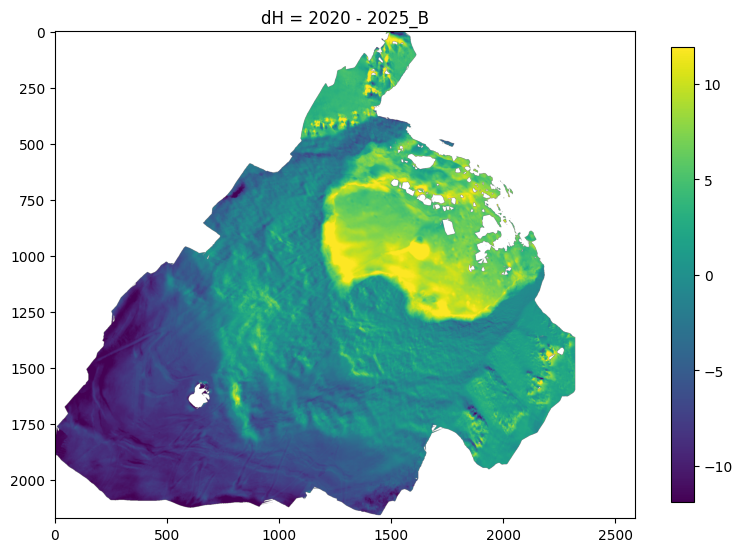

stable mean/median/std/nmad: -0.8676242898118031 -0.681640625 5.878067981030016 6.23951630859375
full   mean/median/std/nmad: -0.8676242898118031 -0.681640625 5.878067981030016 6.23951630859375
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/dod/maps/2020_vs_2025_B_dh.tif
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/dod/figures/2020_vs_2025_B_dh.png

[2023] ==============================================
selected_path   : /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_selected/2023_DSM_selected.tif
selected_product: corrected
decision        : use_corrected_nearly_neutral


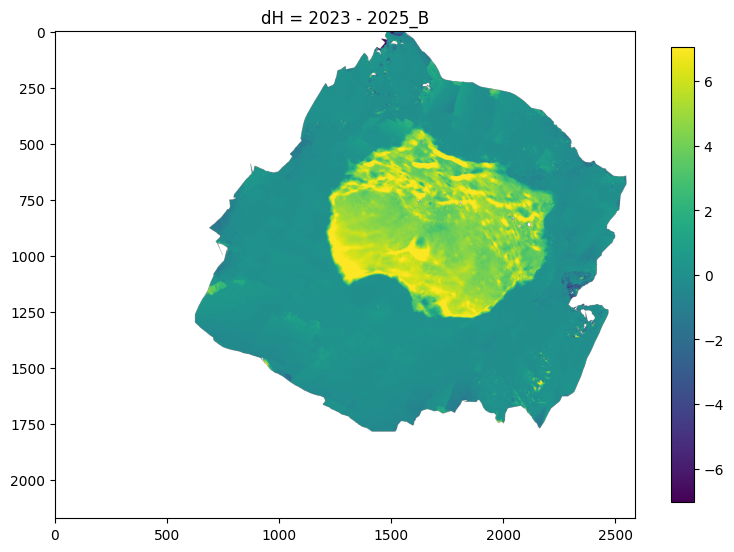

stable mean/median/std/nmad: 1.2856792646567055 0.091796875 2.31137806107986 0.32359482421874997
full   mean/median/std/nmad: 1.2856792646567055 0.091796875 2.31137806107986 0.32359482421874997
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/dod/maps/2023_vs_2025_B_dh.tif
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/dod/figures/2023_vs_2025_B_dh.png

[2025_A] ==============================================
selected_path   : /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_selected/2025_A_DSM_selected.tif
selected_product: original
decision        : use_original


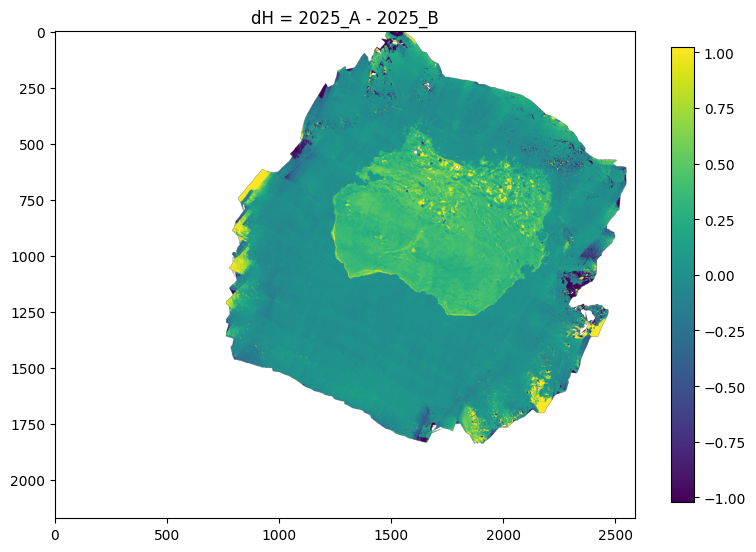

stable mean/median/std/nmad: 0.10324117624000652 0.025390625 0.4496950781338969 0.0970060546875
full   mean/median/std/nmad: 0.10324117624000652 0.025390625 0.4496950781338969 0.0970060546875
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/dod/maps/2025_A_vs_2025_B_dh.tif
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/dod/figures/2025_A_vs_2025_B_dh.png


In [10]:
summary_records = []

for _, row in target_rows.iterrows():
    epoch = str(row['epoch']).strip()
    selected_path = Path(row['selected_path'])
    selected_product = str(row['selected_product']).strip()
    decision = str(row['decision']).strip()

    print(f'\n[{epoch}] ==============================================')
    print('selected_path   :', selected_path)
    print('selected_product:', selected_product)
    print('decision        :', decision)

    assert selected_path.exists(), f'No existe selected_path para {epoch}: {selected_path}'

    target_dem = xdem.DEM(selected_path).reproject(base_dem)
    target_arr = bool_data_from_dem(target_dem)

    valid_target = np.isfinite(target_arr) & (target_arr != -9999)
    valid_all = base_valid & valid_target

    dh_dem = target_dem - base_dem
    dh_arr = bool_data_from_dem(dh_dem).astype('float32')

    stable_eval_mask = stable_mask & valid_all
    dh_stable = dh_arr[stable_eval_mask]

    full_eval_mask = valid_all
    dh_full = dh_arr[full_eval_mask]

    stable_stats = summarize_dh(dh_stable, 'stable_terrain')
    full_stats = summarize_dh(dh_full, 'full_overlap')

    out_tif = DOD_MAP_DIR / f'{epoch}_vs_{BASE_EPOCH}_dh.tif'
    out_png = DOD_FIG_DIR / f'{epoch}_vs_{BASE_EPOCH}_dh.png'

    summary_records.append({
        'epoch': epoch,
        'base_epoch': BASE_EPOCH,
        'selected_product': selected_product,
        'decision': decision,
        'selected_path': str(selected_path),
        'dod_tif': str(out_tif),
        'stable_n': stable_stats['n'],
        'stable_mean': stable_stats['mean'],
        'stable_median': stable_stats['median'],
        'stable_std': stable_stats['std'],
        'stable_nmad': stable_stats['nmad'],
        'stable_p01': stable_stats['p01'],
        'stable_p99': stable_stats['p99'],
        'full_n': full_stats['n'],
        'full_mean': full_stats['mean'],
        'full_median': full_stats['median'],
        'full_std': full_stats['std'],
        'full_nmad': full_stats['nmad'],
        'full_p01': full_stats['p01'],
        'full_p99': full_stats['p99'],
    })

    dh_masked = np.where(valid_all, dh_arr, np.nan).astype('float32')
    save_geotiff(dh_masked, base_dem, out_tif)
    plot_dh_map(dh_masked, epoch, out_png)

    print('stable mean/median/std/nmad:', stable_stats['mean'], stable_stats['median'], stable_stats['std'], stable_stats['nmad'])
    print('full   mean/median/std/nmad:', full_stats['mean'], full_stats['median'], full_stats['std'], full_stats['nmad'])
    print('Guardado:', out_tif)
    print('Guardado:', out_png)

## Tabla resumen DoD

In [11]:
dod_summary_df = pd.DataFrame(summary_records).sort_values('epoch').reset_index(drop=True)
display(dod_summary_df)

,epoch,base_epoch,selected_product,decision,selected_path,dod_tif,stable_n,stable_mean,stable_median,stable_std,stable_nmad,stable_p01,stable_p99,full_n,full_mean,full_median,full_std,full_nmad,full_p01,full_p99
0,2017,2025_B,corrected,use_corrected,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,1774289,3.362523,1.127930,5.265828,3.673199,-5.212402,17.546387,1774289,3.362523,1.127930,5.265828,3.673199,-5.212402,17.546387
1,2020,2025_B,corrected,use_corrected,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,2771784,-0.867624,-0.681641,5.878068,6.239516,-11.687012,12.340820,2771784,-0.867624,-0.681641,5.878068,6.239516,-11.687012,12.340820
2,2023,2025_B,corrected,use_corrected_nearly_neutral,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,2237762,1.285679,0.091797,2.311378,0.323595,-1.061035,7.839355,2237762,1.285679,0.091797,2.311378,0.323595,-1.061035,7.839355
3,2025_A,2025_B,original,use_original,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,2220447,0.103241,0.025391,0.449695,0.097006,-0.839355,1.153809,2220447,0.103241,0.025391,0.449695,0.097006,-0.839355,1.153809


## Ranking por estabilidad residual en terreno estable

In [12]:
dod_ranked_df = dod_summary_df.sort_values(
    by=['stable_nmad', 'stable_median', 'stable_std'],
    ascending=[True, True, True]
).reset_index(drop=True)

display(dod_ranked_df)

,epoch,base_epoch,selected_product,decision,selected_path,dod_tif,stable_n,stable_mean,stable_median,stable_std,stable_nmad,stable_p01,stable_p99,full_n,full_mean,full_median,full_std,full_nmad,full_p01,full_p99
0,2025_A,2025_B,original,use_original,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,2220447,0.103241,0.025391,0.449695,0.097006,-0.839355,1.153809,2220447,0.103241,0.025391,0.449695,0.097006,-0.839355,1.153809
1,2023,2025_B,corrected,use_corrected_nearly_neutral,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,2237762,1.285679,0.091797,2.311378,0.323595,-1.061035,7.839355,2237762,1.285679,0.091797,2.311378,0.323595,-1.061035,7.839355
2,2017,2025_B,corrected,use_corrected,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,1774289,3.362523,1.127930,5.265828,3.673199,-5.212402,17.546387,1774289,3.362523,1.127930,5.265828,3.673199,-5.212402,17.546387
3,2020,2025_B,corrected,use_corrected,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,2771784,-0.867624,-0.681641,5.878068,6.239516,-11.687012,12.340820,2771784,-0.867624,-0.681641,5.878068,6.239516,-11.687012,12.340820


## Exportación

In [13]:
dod_summary_csv = DOD_TABLE_DIR / 'dod_summary.csv'
dod_summary_json = DOD_TABLE_DIR / 'dod_summary.json'
dod_ranked_csv = DOD_TABLE_DIR / 'dod_ranked.csv'

dod_summary_df.to_csv(dod_summary_csv, index=False, encoding='utf-8')
dod_summary_df.to_json(dod_summary_json, orient='records', force_ascii=False, indent=2)
dod_ranked_df.to_csv(dod_ranked_csv, index=False, encoding='utf-8')

print('Guardado:', dod_summary_csv)
print('Guardado:', dod_summary_json)
print('Guardado:', dod_ranked_csv)

Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/dod/tables/dod_summary.csv
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/dod/tables/dod_summary.json
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/dod/tables/dod_ranked.csv


## Árbol de outputs DoD

In [14]:
for p in sorted(DOD_DIR.rglob('*')):
    if p.is_file():
        print(p.relative_to(DOD_DIR), f'({p.stat().st_size / (1024*1024):.2f}MB)')
    else:
        print(p.relative_to(DOD_DIR), '/')

figures /
figures/2017_vs_2025_B_dh.png (0.30MB)
figures/2020_vs_2025_B_dh.png (0.49MB)
figures/2023_vs_2025_B_dh.png (0.33MB)
figures/2025_A_vs_2025_B_dh.png (0.44MB)
maps /
maps/2017_vs_2025_B_dh.tif (4.48MB)
maps/2020_vs_2025_B_dh.tif (6.72MB)
maps/2023_vs_2025_B_dh.tif (5.03MB)
maps/2025_A_vs_2025_B_dh.tif (4.44MB)
tables /
tables/dod_ranked.csv (0.00MB)
tables/dod_summary.csv (0.00MB)
tables/dod_summary.json (0.00MB)


## Qué revisar antes del siguiente módulo

1. `dod_summary_df`
   - verificar que los estadísticos sobre terreno estable sigan siendo razonables.
2. mapas PNG de `outputs/dod/figures/`
   - revisar si el patrón espacial de dH es coherente.
3. TIFF de `outputs/dod/maps/`
   - estos son los rasters base para análisis glaciar siguiente.
4. `dod_ranked_df`
   - ayuda a identificar epochs con mejor o peor comportamiento residual.

In [15]:
print('=== RESUMEN FINAL ===')
print('Base epoch:', BASE_EPOCH)
if 'dod_summary_df' in globals() and len(dod_summary_df) > 0:
    print('Targets DoD:', ', '.join(dod_summary_df['epoch'].astype(str).tolist()))
    display(dod_summary_df)
else:
    print('Aún no hay resultados.')

=== RESUMEN FINAL ===
Base epoch: 2025_B
Targets DoD: 2017, 2020, 2023, 2025_A


,epoch,base_epoch,selected_product,decision,selected_path,dod_tif,stable_n,stable_mean,stable_median,stable_std,stable_nmad,stable_p01,stable_p99,full_n,full_mean,full_median,full_std,full_nmad,full_p01,full_p99
0,2017,2025_B,corrected,use_corrected,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,1774289,3.362523,1.127930,5.265828,3.673199,-5.212402,17.546387,1774289,3.362523,1.127930,5.265828,3.673199,-5.212402,17.546387
1,2020,2025_B,corrected,use_corrected,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,2771784,-0.867624,-0.681641,5.878068,6.239516,-11.687012,12.340820,2771784,-0.867624,-0.681641,5.878068,6.239516,-11.687012,12.340820
2,2023,2025_B,corrected,use_corrected_nearly_neutral,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,2237762,1.285679,0.091797,2.311378,0.323595,-1.061035,7.839355,2237762,1.285679,0.091797,2.311378,0.323595,-1.061035,7.839355
3,2025_A,2025_B,original,use_original,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,2220447,0.103241,0.025391,0.449695,0.097006,-0.839355,1.153809,2220447,0.103241,0.025391,0.449695,0.097006,-0.839355,1.153809
